In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.integrate import trapezoid

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

# SSR w noise

In [4]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

Found 1345 .mat files


Fitting GMMs: 100%|█████████████████████████████████████████████████████████████████| 1345/1345 [02:58<00:00,  7.55it/s]


In [5]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
excluded_label = 2
excluded_label_name = synth_ds.classes[excluded_label]
print(f"Excluding label {excluded_label} ({excluded_label_name}) from synthetic dataset")
new_synth_ds = RemappedSubset(synth_ds, exclude_label=excluded_label)

Excluding label 2 (btr70) from synthetic dataset


In [7]:
train_ds = new_synth_ds
test_ds = meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [8]:
seed_lst = [42]

label_lst = []
prob_lst = []
pred_lst = []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx) - 1)
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/OOD/SSR_w_noise/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
            inputs = inputs.to(device)
    
            outputs = new_model(inputs)
            probs = F.softmax(outputs, dim=1)
            confidence, preds = torch.max(probs, dim=1)
    
            prob_lst.append(confidence.cpu())
            pred_lst.append(preds.cpu())
            label_lst.append(labels)  # already on cpu from dataloader

confidences = torch.cat(prob_lst).numpy()
preds = torch.cat(pred_lst).numpy()
labels = torch.cat(label_lst).numpy()

inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}

preds_og = np.array([
    inv_label_map[p] for p in preds
])

Evaluating Run 0: seed 42


In [11]:
np.unique(labels, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([174, 107,  92, 129, 128, 129, 128, 176, 108, 174]))

In [10]:
np.unique(preds_og, return_counts=True)

(array([0, 1, 3, 4, 5, 6, 7, 8, 9]),
 array([247, 106, 152, 157,  75,  98, 176, 108, 226]))

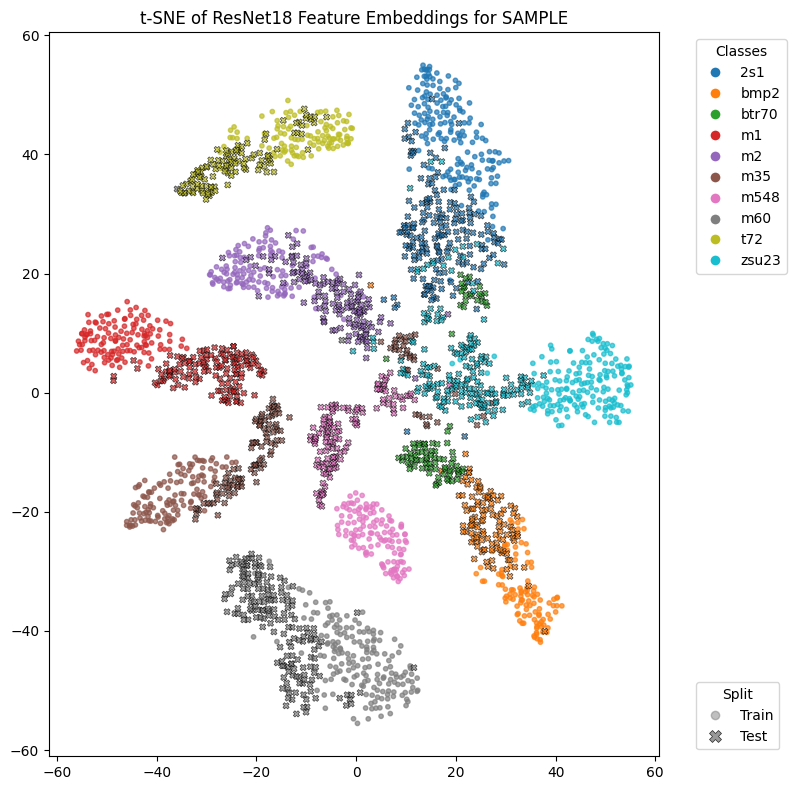

In [12]:
combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.dataset.class_to_idx) - 1)
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/OOD/SSR_w_noise/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}
train_labels = np.array([inv_label_map[l] for l in labels_list[:len(train_ds)]])
test_labels = labels_list[len(train_ds):]
labels_list = np.concatenate([train_labels, test_labels])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(test_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

cmap = plt.cm.tab10
norm = plt.Normalize(vmin=0, vmax=n_classes - 1)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", 
           markerfacecolor=cmap(norm(i)), markersize=8, label=class_names[i])
    for i in range(n_classes)
]

class_legend = plt.legend(
    handles=legend_handles,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

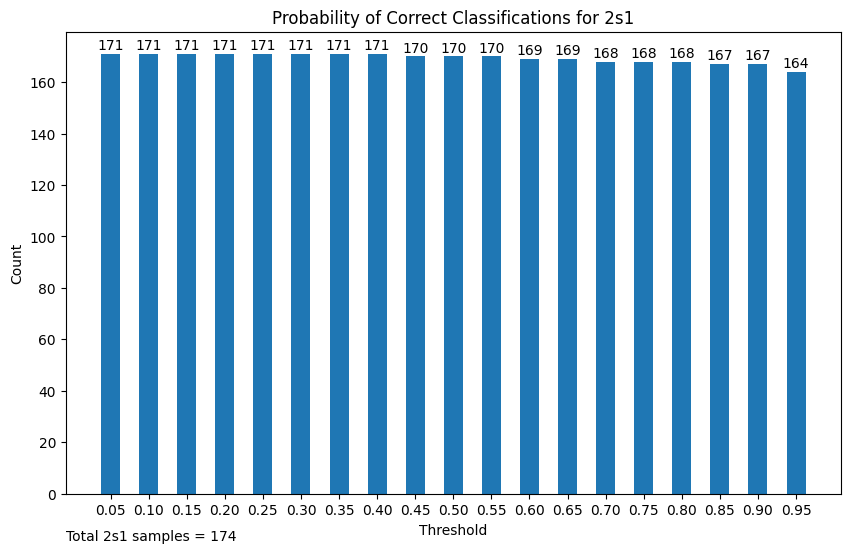

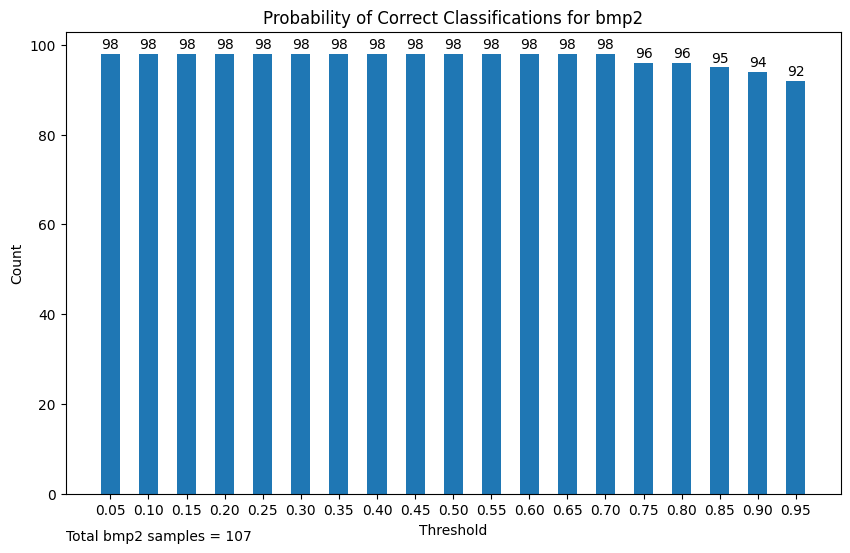

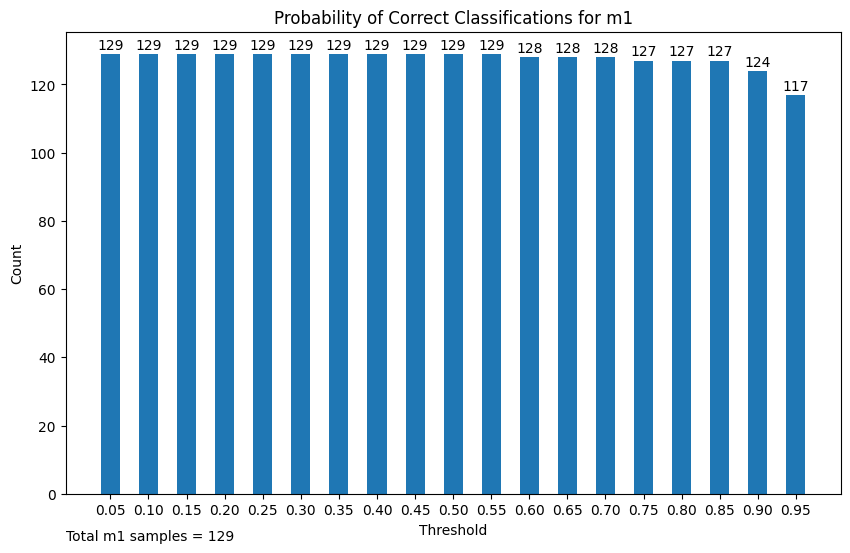

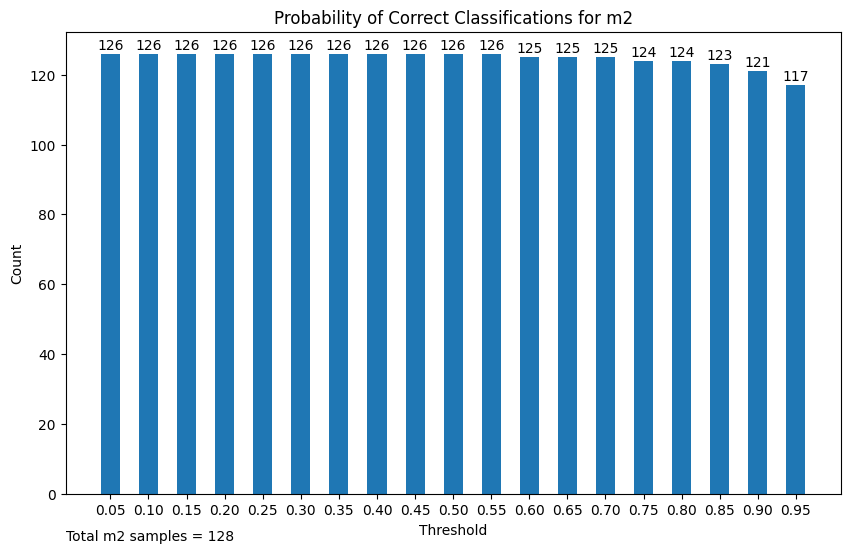

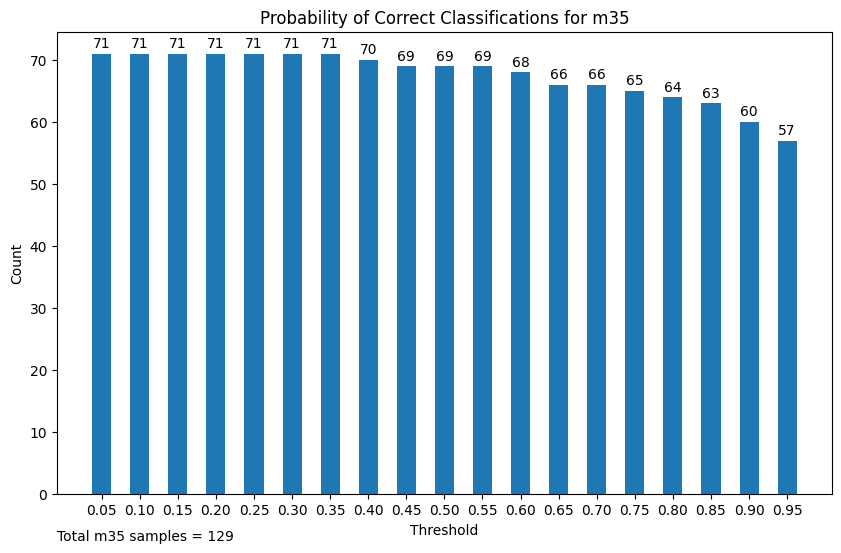

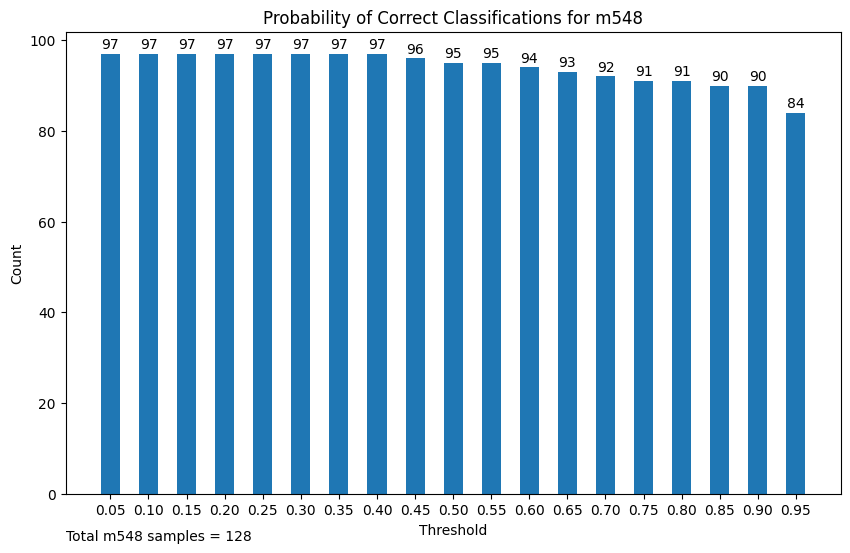

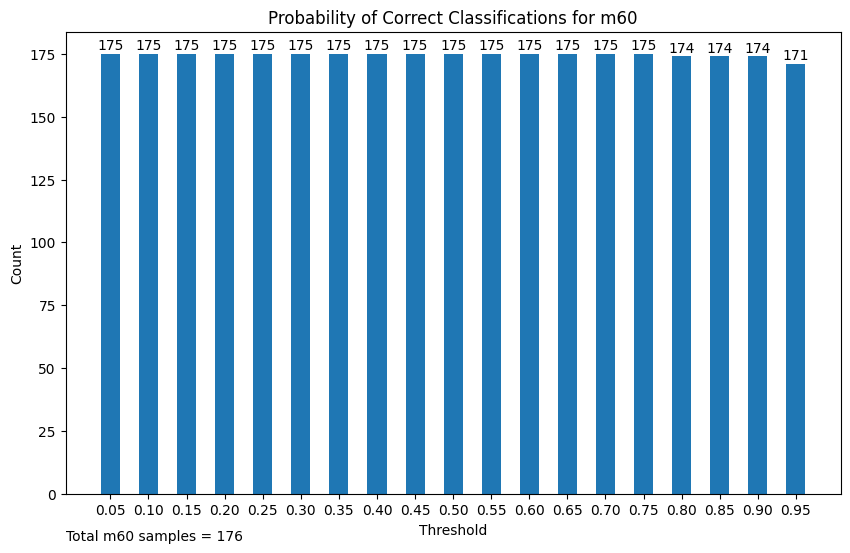

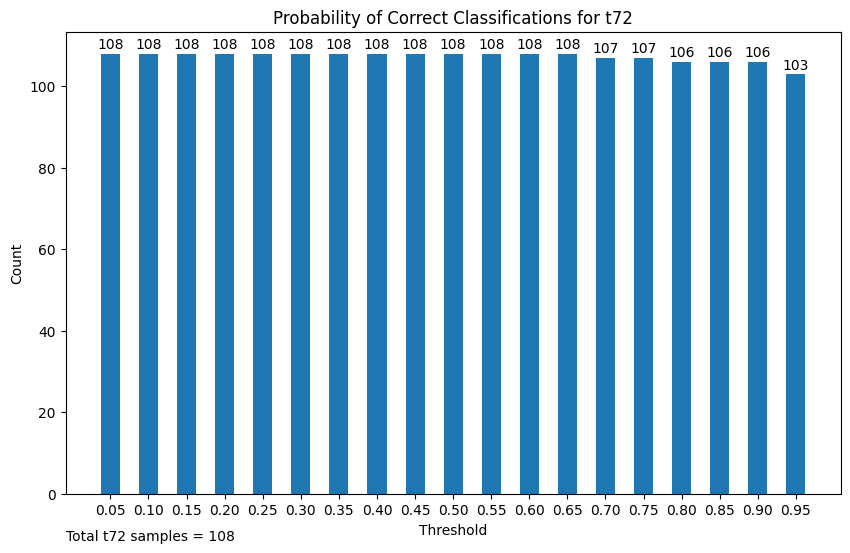

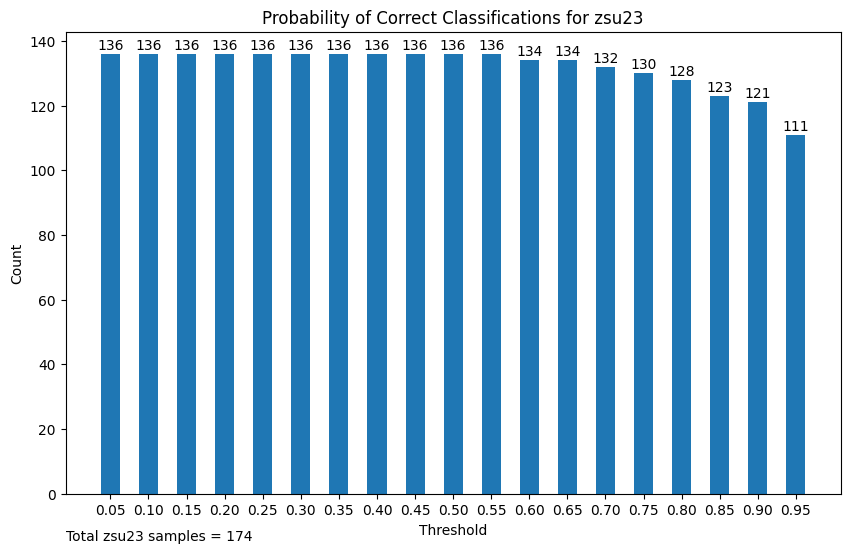

In [12]:
for j in list(inv_label_map.values()):
    class_label = j
    
    threshold = np.arange(0.05, 1.0, 0.05)
    count_above_threshold = []
    for t in threshold:
        correct_mask = ((labels == class_label) & (preds_og == class_label))
        correct_conf = confidences[correct_mask]
        count_above_threshold.append(np.sum(correct_conf >= t))
    count_above_threshold = np.array(count_above_threshold)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.bar(threshold, count_above_threshold, width=0.025, align='center')

    pltlocs, pltticks = plt.xticks()
    ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

    for i, count in enumerate(count_above_threshold):
        ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

    ax.text(0, -0.1, f"Total {meas_ds.classes[j]} samples = {(labels == class_label).sum()}", transform=ax.transAxes)

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Count')
    ax.set_title(f'Probability of Correct Classifications for {meas_ds.classes[j]}')
    plt.show()


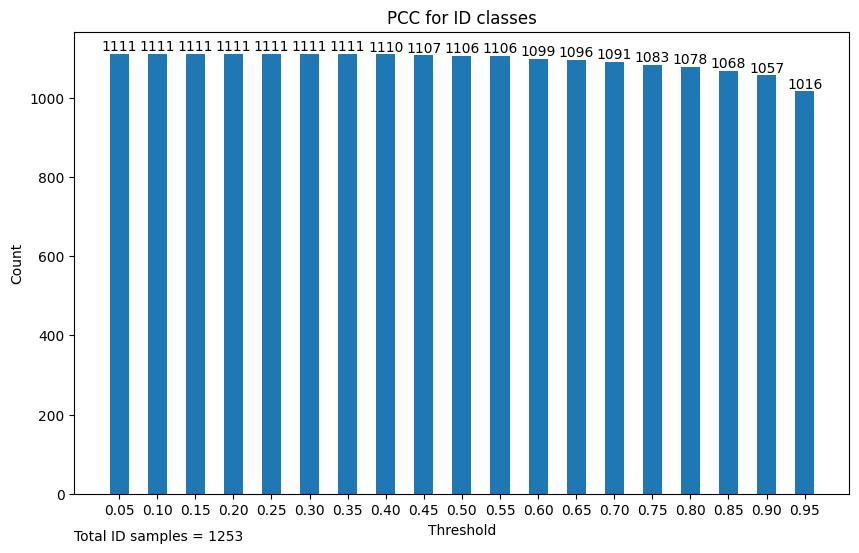

In [13]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold = []
for t in threshold:
    correct_mask = ((labels == preds_og))
    correct_conf = confidences[correct_mask]
    count_above_threshold.append(np.sum(correct_conf >= t))
count_above_threshold = np.array(count_above_threshold)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold, width=0.025, align='center')

pltlocs, pltticks = plt.xticks()
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold):
    ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples = {(labels != excluded_label).sum()}", transform=ax.transAxes)

ax.set_xlabel('Threshold')
ax.set_ylabel('Count')
ax.set_title(f'PCC for ID classes')
plt.show()

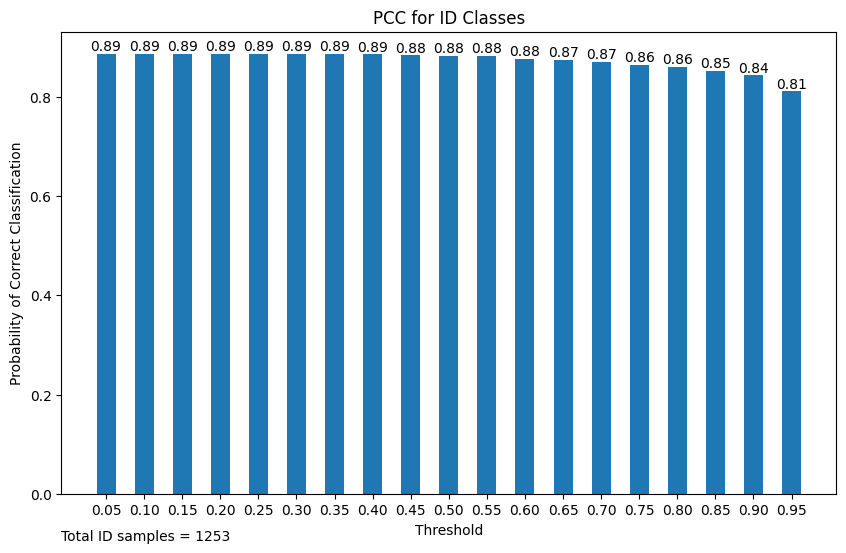

In [14]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold = []
for t in threshold:
    correct_mask = ((labels == preds_og))
    correct_conf = confidences[correct_mask]
    count_above_threshold.append(np.sum(correct_conf >= t))
count_above_threshold = np.array(count_above_threshold)

ID_sum = (labels != excluded_label).sum()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold/ID_sum, width=0.025, align='center')

pltlocs, pltticks = plt.xticks()
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold/ID_sum):
    ax.text(threshold[i], count, f"{count:.2f}", ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples = {ID_sum}", transform=ax.transAxes)

ax.set_xlabel('Threshold')
ax.set_ylabel('Probability of Correct Classification')
ax.set_title(f'PCC for ID Classes')
plt.show()

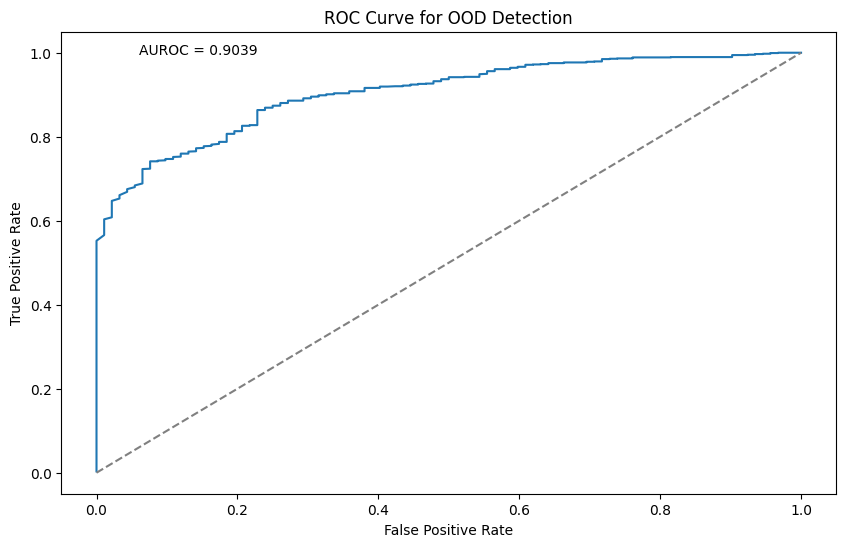

In [15]:
"""
Definitions: 
ID: probability >= threshold
OOD: probability < threshold

Thus, 
Positive = ID
Negative = OOD

False Positive = False ID = OOD labelled as ID
False Negative = False OOD = ID labelled as OOD

True Positive = True ID = ID labelled as ID
True Negative = True OOD = OOD labelled as OOD

TPR = TP / (TP + FN) = TP / ID_dist
FPR = FP / (FP + TN) = FP / OOD_dist
"""
step = 0.0001
threshold = np.arange(0, 1 + step, step)
TPR_lst = []
ID_mask = (labels != excluded_label)
for t in threshold:
    correct_conf = confidences[ID_mask]
    TPR_lst.append(
        (np.sum(correct_conf >= t)) / (ID_mask.sum())
        )
TPR_lst = np.array(TPR_lst)

OOD_mask = (labels == excluded_label)

FPR_lst = []
for t in threshold:
    false_alarm = (OOD_mask & (confidences >= t)).sum()
    FPR_lst.append(
        false_alarm/OOD_mask.sum()
        )
FPR_lst = np.array(FPR_lst)

sort_idx = np.argsort(FPR_lst)
fpr_sorted = FPR_lst[sort_idx]
tpr_sorted = TPR_lst[sort_idx]

auroc = trapezoid(y=tpr_sorted, x=fpr_sorted) 
# higher auroc is better
# 1.0 is perfect, 0.5 is random guessing, <0.5 is worse than random guessing

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(FPR_lst, TPR_lst)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Add diagonal line for reference
ax.text(0.1, 0.95, f'AUROC = {auroc:.4f}', transform = ax.transAxes)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for OOD Detection')
plt.show()

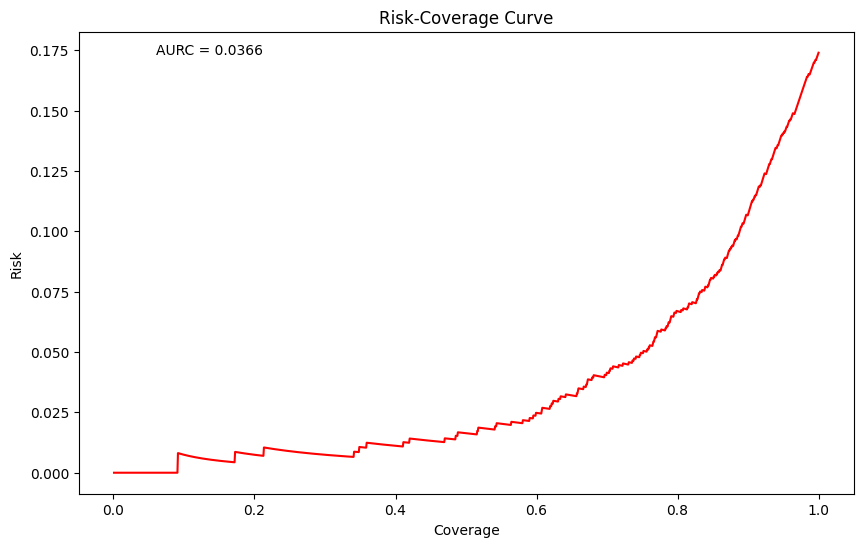

In [13]:
# Risk-Coverage Curve

sorted_idx = np.argsort(confidences)[::-1]  # Sort in most confident to least confident order
sorted_labels = labels[sorted_idx]
sorted_preds = preds_og[sorted_idx]

wrong_preds = (sorted_labels != sorted_preds)
cumulative_wrong = np.cumsum(wrong_preds)
cumulative_preds = np.arange(1, len(labels) + 1)

risk = cumulative_wrong / cumulative_preds
coverage = cumulative_preds / len(labels)

aurc = trapezoid(y=risk, x=coverage) # lower aurc is better, as it means lower risk at higher coverage

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(coverage, risk, c = "r")
ax.text(0.1, 0.95, f'AURC = {aurc:.4f}', transform = ax.transAxes)
ax.set_xlabel('Coverage')
ax.set_ylabel('Risk')
ax.set_title('Risk-Coverage Curve')
plt.show()

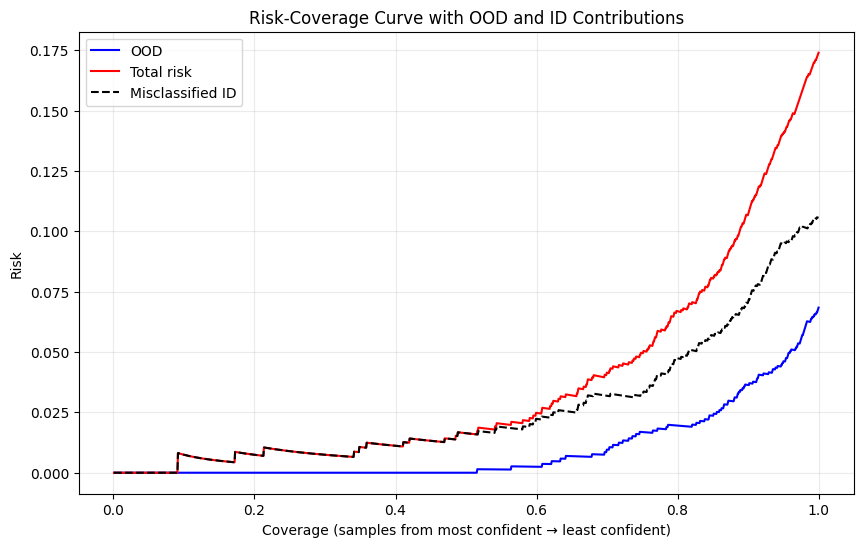

In [13]:
sorted_idx = np.argsort(confidences)[::-1]
sorted_labels = labels[sorted_idx]
sorted_preds = preds_og[sorted_idx]

is_ood_sorted = (sorted_labels == excluded_label)
is_wrong_sorted = (sorted_labels != sorted_preds)

# Curve 1: only OOD counts as wrong (misclassified ID ignored)
curve_one_wrong = is_ood_sorted  # OOD is always wrong, misclassified ID = not counted
cumulative_wrong_curve_one = np.cumsum(curve_one_wrong)

# Curve 2: everything wrong
cumulative_wrong_curve_two = np.cumsum(is_wrong_sorted)

# Curve 3: difference = misclassified ID contribution (naturally same length now)
curve_three = cumulative_wrong_curve_two - cumulative_wrong_curve_one

# Shared x-axis
n = len(sorted_labels)
cumulative_preds = np.arange(1, n + 1)

coverage = cumulative_preds / n

ood_risk = cumulative_wrong_curve_one / cumulative_preds     # OOD contribution
id_miss_risk = curve_three / cumulative_preds                # misclassified ID contribution
total_risk = cumulative_wrong_curve_two / cumulative_preds          # same as original RC curve

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(coverage, ood_risk, label="OOD", color='b')
ax.plot(coverage, total_risk, label="Total risk", color='r')
ax.plot(coverage, id_miss_risk, label="Misclassified ID", color='k', linestyle='--')
ax.grid(True, alpha = 0.25)
ax.set_xlabel("Coverage (samples from most confident → least confident)")
ax.set_ylabel("Risk")
ax.set_title("Risk-Coverage Curve with OOD and ID Contributions")
ax.legend()
plt.show()

# wo aug

In [14]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [15]:
excluded_label = 2
excluded_label_name = synth_ds.classes[excluded_label]
print(f"Excluding label {excluded_label} ({excluded_label_name}) from synthetic dataset")
new_synth_ds = RemappedSubset(synth_ds, exclude_label=excluded_label)

Excluding label 2 (btr70) from synthetic dataset


In [16]:
train_ds = new_synth_ds
test_ds = meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [17]:
seed_lst = [42]

label_lst = []
prob_lst = []
pred_lst = []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx) - 1)
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/OOD/wo_aug/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
            inputs = inputs.to(device)
    
            outputs = new_model(inputs)
            probs = F.softmax(outputs, dim=1)
            confidence, preds = torch.max(probs, dim=1)
    
            prob_lst.append(confidence.cpu())
            pred_lst.append(preds.cpu())
            label_lst.append(labels)  # already on cpu from dataloader

confidences = torch.cat(prob_lst).numpy()
preds = torch.cat(pred_lst).numpy()
labels = torch.cat(label_lst).numpy()

inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}

preds_og = np.array([
    inv_label_map[p] for p in preds
])

Evaluating Run 0: seed 42


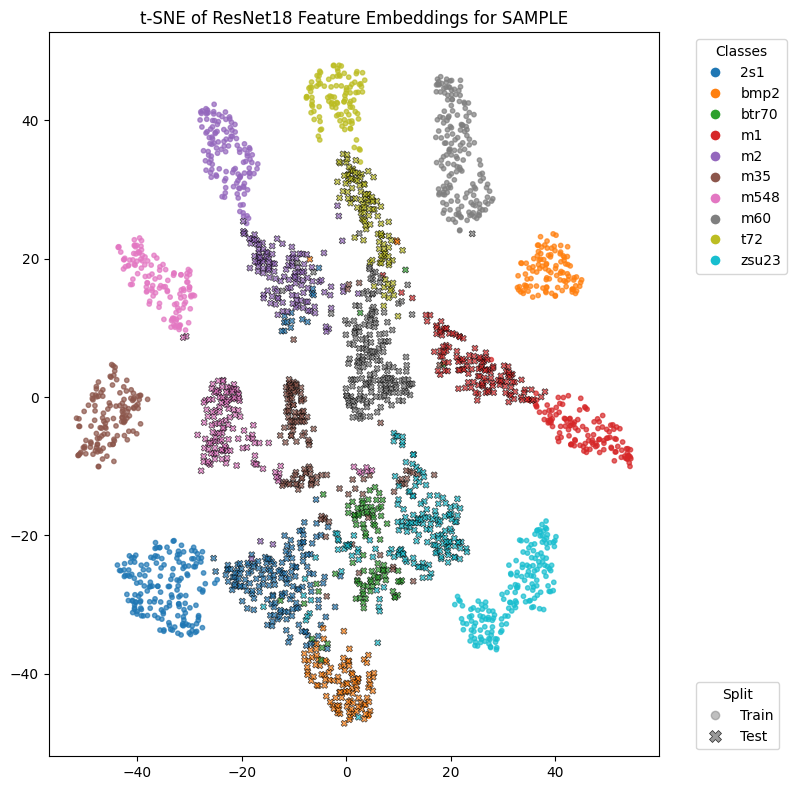

In [18]:
combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.dataset.class_to_idx) - 1)
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/OOD/wo_aug/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}
train_labels = np.array([inv_label_map[l] for l in labels_list[:len(train_ds)]])
test_labels = labels_list[len(train_ds):]
labels_list = np.concatenate([train_labels, test_labels])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(test_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

cmap = plt.cm.tab10
norm = plt.Normalize(vmin=0, vmax=n_classes - 1)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", 
           markerfacecolor=cmap(norm(i)), markersize=8, label=class_names[i])
    for i in range(n_classes)
]

class_legend = plt.legend(
    handles=legend_handles,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

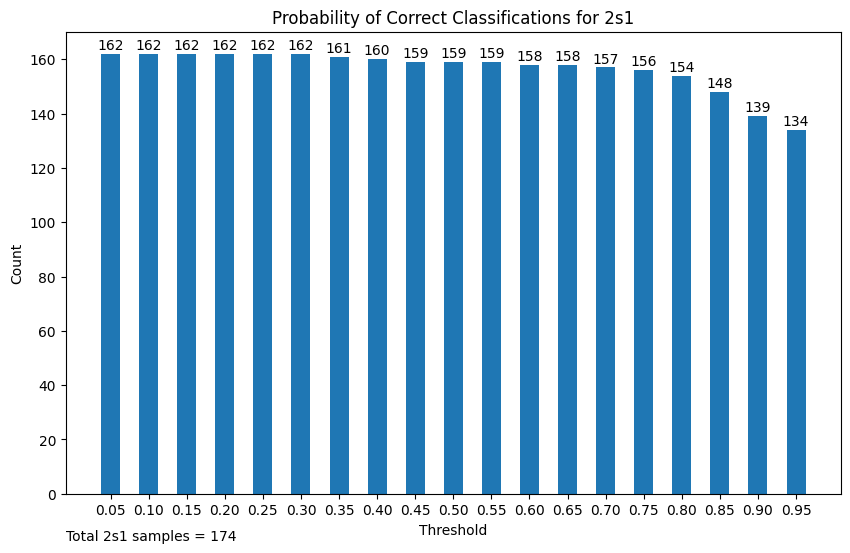

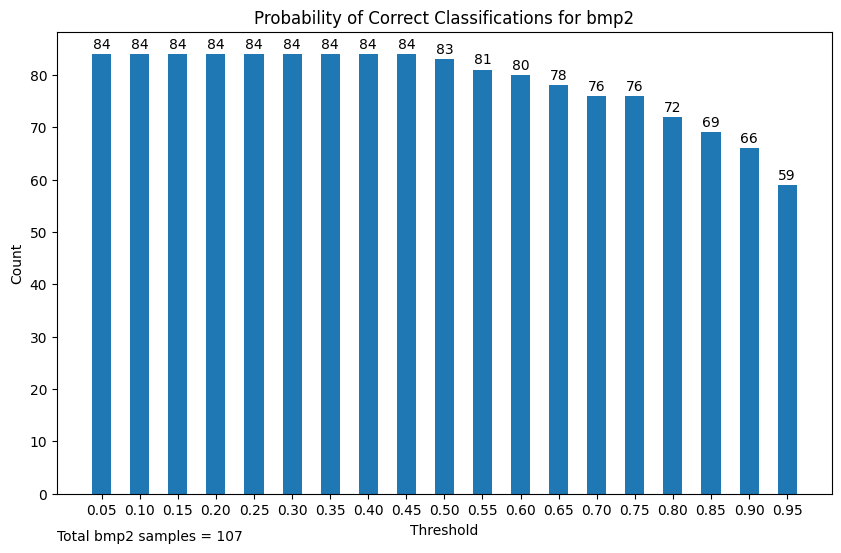

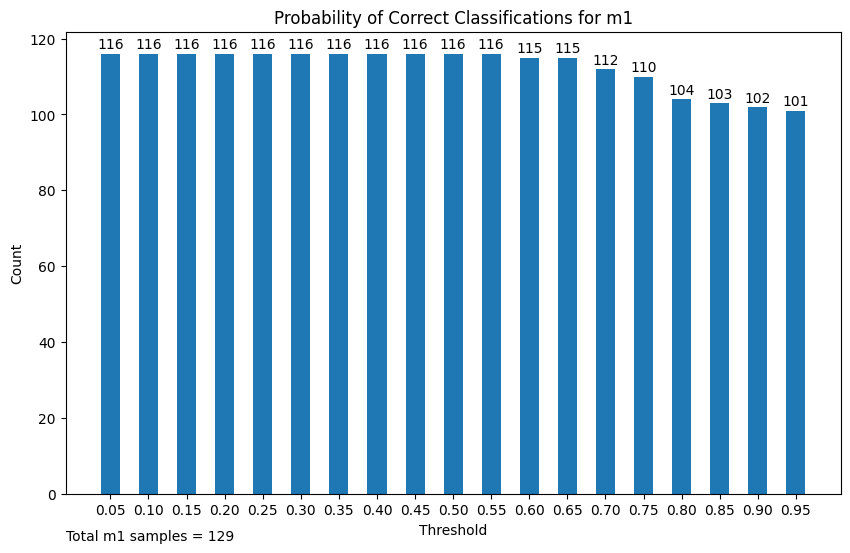

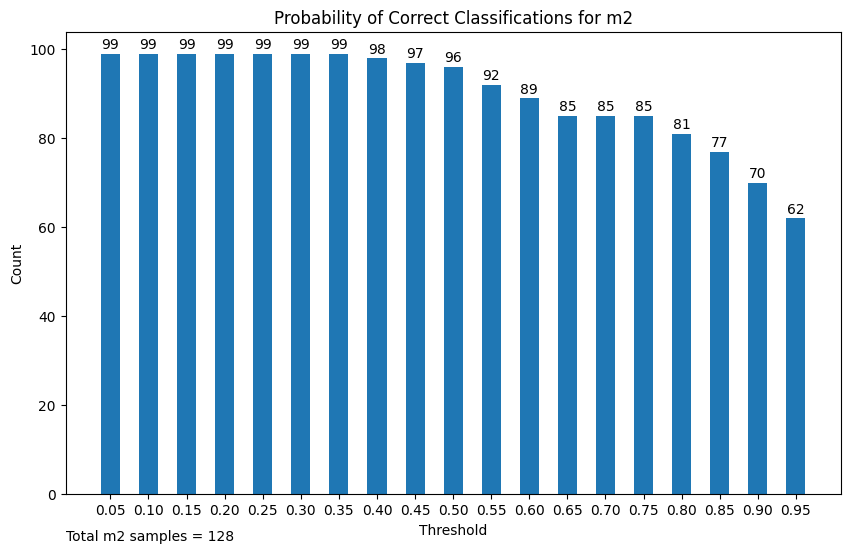

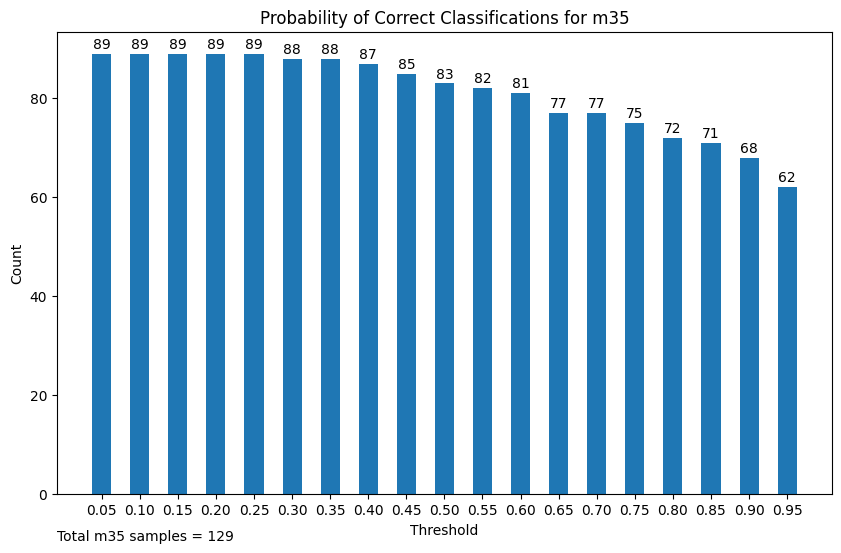

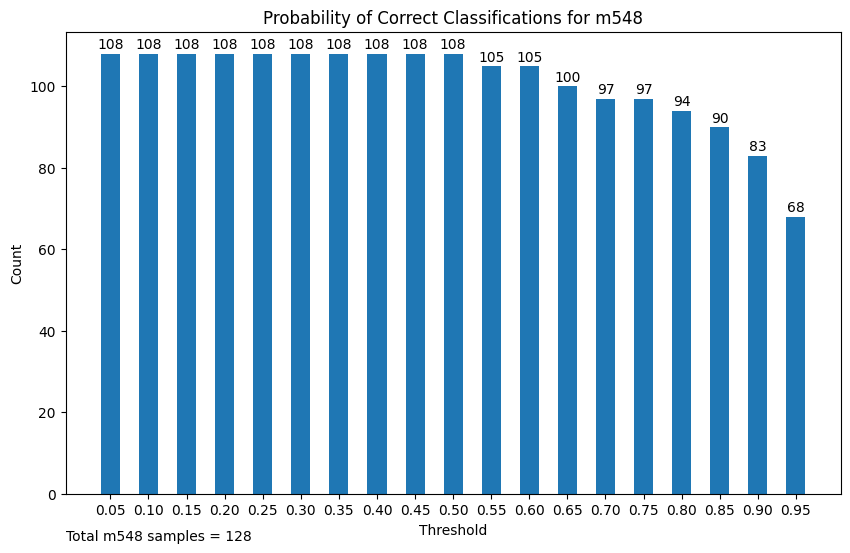

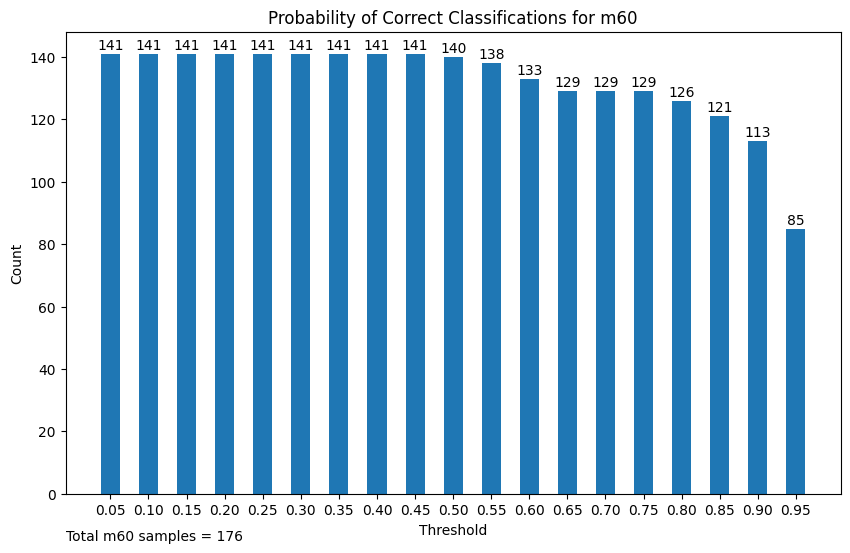

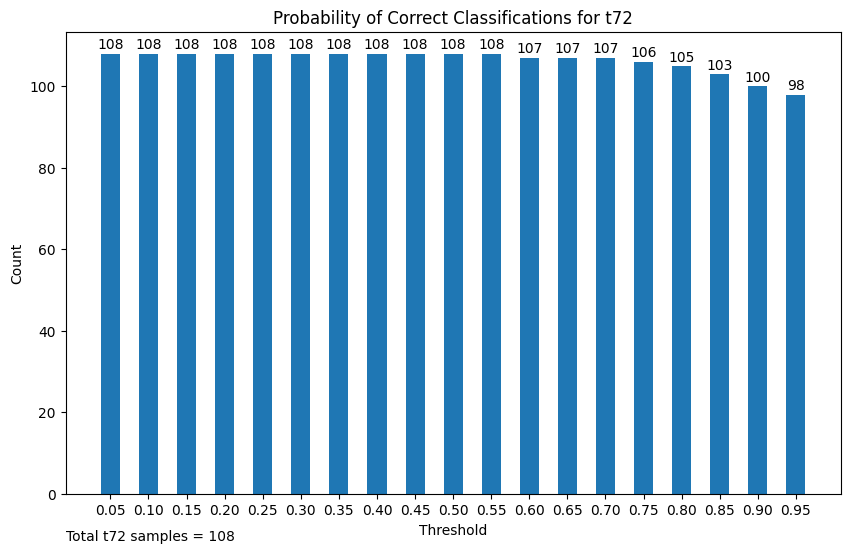

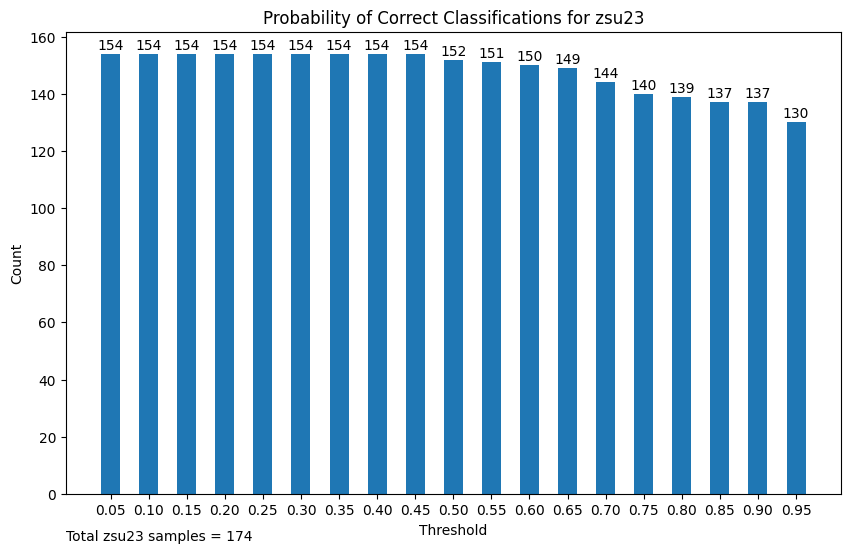

In [22]:
for j in list(inv_label_map.values()):
    class_label = j
    
    threshold = np.arange(0.05, 1.0, 0.05)
    count_above_threshold = []
    for t in threshold:
        correct_mask = ((labels == class_label) & (preds_og == class_label))
        correct_conf = confidences[correct_mask]
        count_above_threshold.append(np.sum(correct_conf >= t))
    count_above_threshold = np.array(count_above_threshold)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.bar(threshold, count_above_threshold, width=0.025, align='center')

    pltlocs, pltticks = plt.xticks()
    ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

    for i, count in enumerate(count_above_threshold):
        ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

    ax.text(0, -0.1, f"Total {meas_ds.classes[j]} samples = {(labels == class_label).sum()}", transform=ax.transAxes)

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Count')
    ax.set_title(f'Probability of Correct Classifications for {meas_ds.classes[j]}')
    plt.show()


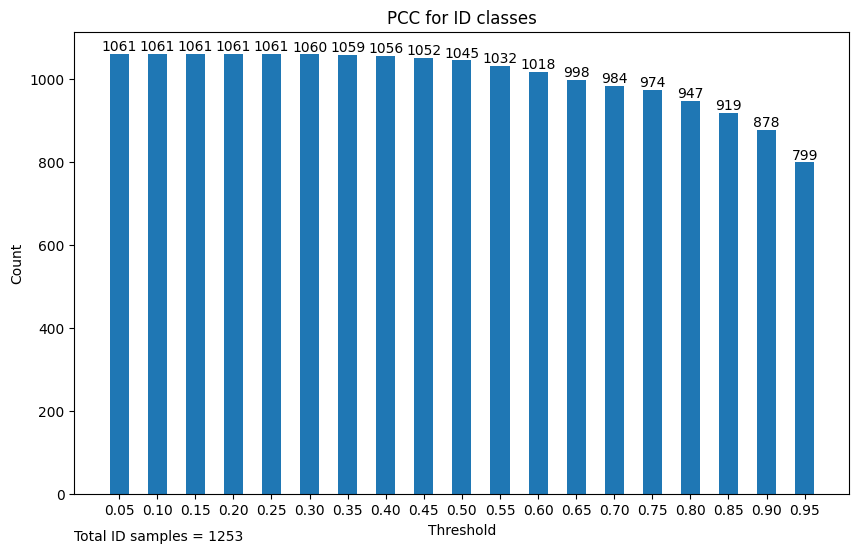

In [23]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold = []
for t in threshold:
    correct_mask = ((labels == preds_og))
    correct_conf = confidences[correct_mask]
    count_above_threshold.append(np.sum(correct_conf >= t))
count_above_threshold = np.array(count_above_threshold)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold, width=0.025, align='center')

pltlocs, pltticks = plt.xticks()
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold):
    ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples = {(labels != excluded_label).sum()}", transform=ax.transAxes)

ax.set_xlabel('Threshold')
ax.set_ylabel('Count')
ax.set_title(f'PCC for ID classes')
plt.show()

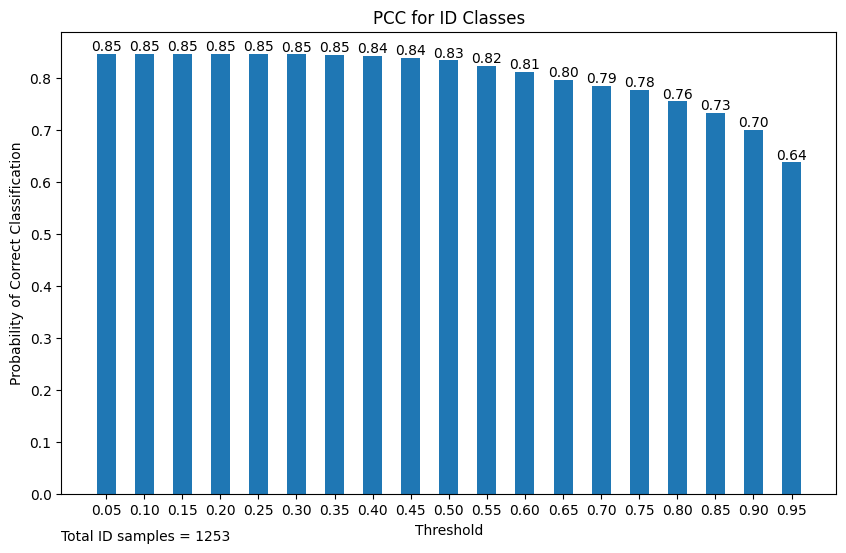

In [24]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold = []
for t in threshold:
    correct_mask = ((labels == preds_og))
    correct_conf = confidences[correct_mask]
    count_above_threshold.append(np.sum(correct_conf >= t))
count_above_threshold = np.array(count_above_threshold)

ID_sum = (labels != excluded_label).sum()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold/ID_sum, width=0.025, align='center')

pltlocs, pltticks = plt.xticks()
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold/ID_sum):
    ax.text(threshold[i], count, f"{count:.2f}", ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples = {ID_sum}", transform=ax.transAxes)

ax.set_xlabel('Threshold')
ax.set_ylabel('Probability of Correct Classification')
ax.set_title(f'PCC for ID Classes')
plt.show()

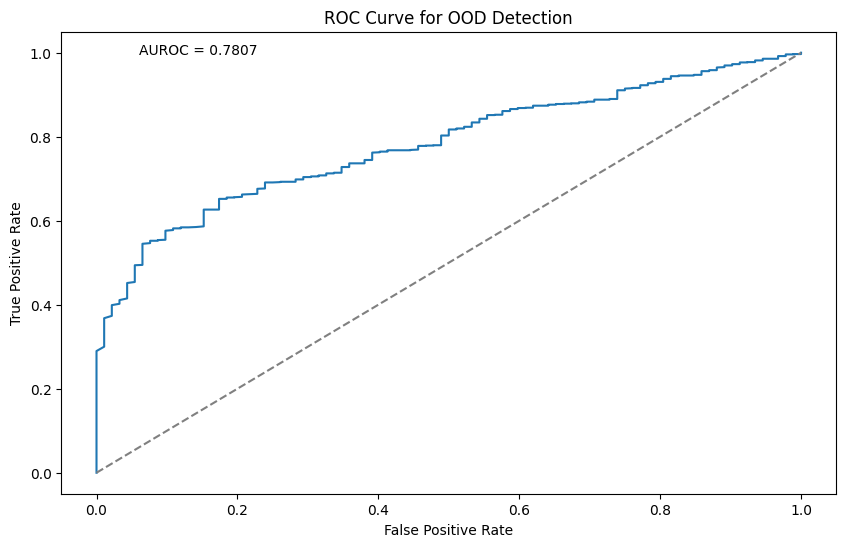

In [25]:
"""
Definitions: 
ID: probability >= threshold
OOD: probability < threshold

Thus, 
Positive = ID
Negative = OOD

False Positive = False ID = OOD labelled as ID
False Negative = False OOD = ID labelled as OOD

True Positive = True ID = ID labelled as ID
True Negative = True OOD = OOD labelled as OOD

TPR = TP / (TP + FN) = TP / ID_dist
FPR = FP / (FP + TN) = FP / OOD_dist
"""
step = 0.0001
threshold = np.arange(0, 1 + step, step)
TPR_lst = []
ID_mask = (labels != excluded_label)
for t in threshold:
    correct_conf = confidences[ID_mask]
    TPR_lst.append(
        (np.sum(correct_conf >= t)) / (ID_mask.sum())
        )
TPR_lst = np.array(TPR_lst)

OOD_mask = (labels == excluded_label)

FPR_lst = []
for t in threshold:
    false_alarm = (OOD_mask & (confidences >= t)).sum()
    FPR_lst.append(
        false_alarm/OOD_mask.sum()
        )
FPR_lst = np.array(FPR_lst)

sort_idx = np.argsort(FPR_lst)
fpr_sorted = FPR_lst[sort_idx]
tpr_sorted = TPR_lst[sort_idx]

auroc = trapezoid(y=tpr_sorted, x=fpr_sorted) 
# higher auroc is better
# 1.0 is perfect, 0.5 is random guessing, <0.5 is worse than random guessing

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(FPR_lst, TPR_lst)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Add diagonal line for reference
ax.text(0.1, 0.95, f'AUROC = {auroc:.4f}', transform = ax.transAxes)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for OOD Detection')
plt.show()

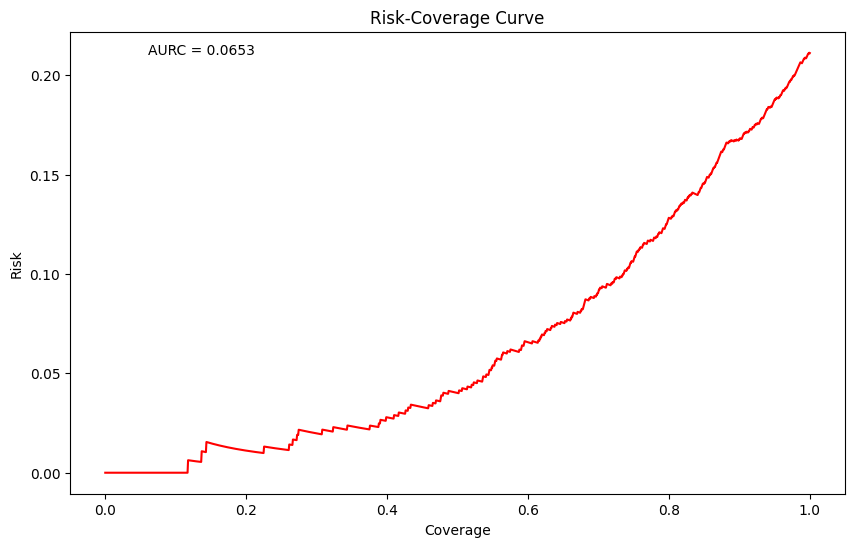

In [20]:
# Risk-Coverage Curve

sorted_idx = np.argsort(confidences)[::-1]  # Sort in most confident to least confident order
sorted_labels = labels[sorted_idx]
sorted_preds = preds_og[sorted_idx]

wrong_preds = (sorted_labels != sorted_preds)
cumulative_wrong = np.cumsum(wrong_preds)
cumulative_preds = np.arange(1, len(labels) + 1)

risk = cumulative_wrong / cumulative_preds
coverage = cumulative_preds / len(labels)

aurc = trapezoid(y=risk, x=coverage) # lower aurc is better, as it means lower risk at higher coverage

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(coverage, risk, c = "r")
ax.text(0.1, 0.95, f'AURC = {aurc:.4f}', transform = ax.transAxes)
ax.set_xlabel('Coverage')
ax.set_ylabel('Risk')
ax.set_title('Risk-Coverage Curve')
plt.show()

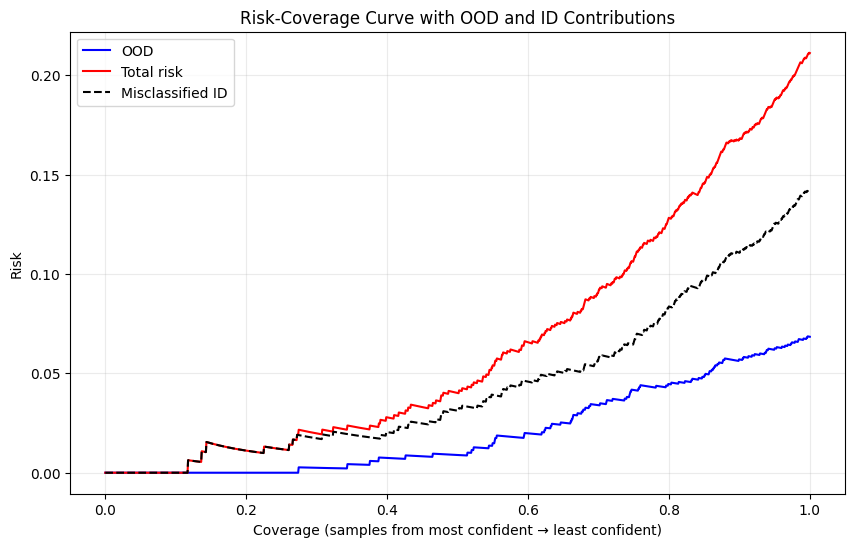

In [19]:
sorted_idx = np.argsort(confidences)[::-1]
sorted_labels = labels[sorted_idx]
sorted_preds = preds_og[sorted_idx]

is_ood_sorted = (sorted_labels == excluded_label)
is_wrong_sorted = (sorted_labels != sorted_preds)

# Curve 1: only OOD counts as wrong (misclassified ID ignored)
curve_one_wrong = is_ood_sorted  # OOD is always wrong, misclassified ID = not counted
cumulative_wrong_curve_one = np.cumsum(curve_one_wrong)

# Curve 2: everything wrong
cumulative_wrong_curve_two = np.cumsum(is_wrong_sorted)

# Curve 3: difference = misclassified ID contribution (naturally same length now)
curve_three = cumulative_wrong_curve_two - cumulative_wrong_curve_one

# Shared x-axis
n = len(sorted_labels)
cumulative_preds = np.arange(1, n + 1)

coverage = cumulative_preds / n

ood_risk = cumulative_wrong_curve_one / cumulative_preds     # OOD contribution
id_miss_risk = curve_three / cumulative_preds                # misclassified ID contribution
total_risk = cumulative_wrong_curve_two / cumulative_preds          # same as original RC curve

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(coverage, ood_risk, label="OOD", color='b')
ax.plot(coverage, total_risk, label="Total risk", color='r')
ax.plot(coverage, id_miss_risk, label="Misclassified ID", color='k', linestyle='--')
ax.grid(True, alpha = 0.25)
ax.set_xlabel("Coverage (samples from most confident → least confident)")
ax.set_ylabel("Risk")
ax.set_title("Risk-Coverage Curve with OOD and ID Contributions")
ax.legend()
plt.show()